# Twin Gaussian Shell Evidence with NumPyro + MorphZ

This notebook demonstrates how to estimate the Bayesian evidence (log marginal likelihood, **ln Z**) for the **twin Gaussian shell** benchmark problem using:

- **NumPyro** for posterior sampling (via NUTS with multi-chain initialisation)
- **MorphZ** for evidence estimation from posterior samples

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/EL-MZ/MorphZ/blob/main/examples/numpyro_gaussian_shell.ipynb)

## 1. What We Are Computing

The **twin Gaussian shell** is a standard multimodal benchmark from nested-sampling literature.  
Parameters $\theta \in \mathbb{R}^D$ live in a uniform prior box $[-L, L]^D$.

**Prior:**
$$
p(\theta) = \frac{1}{(2L)^D}
$$

**Likelihood** (sum of two thin spherical shells, eq. 38 in the MorphZ paper):
$$
\mathcal{L}(\theta) = \frac{1}{\sqrt{2\pi w^2}}\exp\!\left[-\frac{(|\theta - c_1| - r)^2}{2w^2}\right]
              + \frac{1}{\sqrt{2\pi w^2}}\exp\!\left[-\frac{(|\theta - c_2| - r)^2}{2w^2}\right]
$$

with $c_1 = (-3.5, 0, \ldots)$, $c_2 = (3.5, 0, \ldots)$, $r = 2$, $w = 0.1$.

**Challenge:** The two shells are completely disconnected — a standard NUTS chain started in one shell will never jump to the other.  
We handle this by running **4 chains** with 2 initialised near each shell center, then combining all samples before passing them to MorphZ.

**Evidence:**
$$
Z = \int p(y \mid \theta)\, p(\theta)\, d\theta
$$

## 2. Colab Setup

In [72]:
%pip -q install "jax[cpu]" numpyro morphz corner

/home/apokrypha/miniconda3/envs/pta/lib/python3.12/pty.py:95: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  pid, fd = os.forkpty()


Note: you may need to restart the kernel to use updated packages.


## 3. Problem Setup

We define the twin-shell geometry and a JAX-compatible log-likelihood.

In [8]:
import numpy as np
import jax
import jax.numpy as jnp
import numpyro
import numpyro.distributions as dist
import matplotlib.pyplot as plt
import corner

from numpyro.infer import MCMC, NUTS
from numpyro.infer.util import log_density
from morphZ import evidence

print('jax:', jax.__version__)
print('numpyro:', numpyro.__version__)

# ── geometry ──────────────────────────────────────────────────────────────────
L    = 6.0
ndim = 30   # ← change to 10 for the standard benchmark, 30 for the high-dim test
r    = 2.0
w    = 0.1

c1 = jnp.array([-3.5] + [0.0] * (ndim - 1))
c2 = jnp.array([ 3.5] + [0.0] * (ndim - 1))

print(f'ndim = {ndim},  L = {L},  r = {r},  w = {w}')
print(f'c1[0] = {c1[0]:.1f},  c2[0] = {c2[0]:.1f}')

# ── JAX log-likelihood ────────────────────────────────────────────────────────
@jax.jit
def jax_loglikelihood(theta):
    """Twin Gaussian shell log-likelihood (JAX, works on a single parameter vector)."""
    log_norm = -0.5 * jnp.log(2.0 * jnp.pi * w ** 2)
    log_exp1 = log_norm - 0.5 * ((jnp.linalg.norm(theta - c1) - r) / w) ** 2
    log_exp2 = log_norm - 0.5 * ((jnp.linalg.norm(theta - c2) - r) / w) ** 2
    return jax.scipy.special.logsumexp(jnp.array([log_exp1, log_exp2]))

jax: 0.6.2
numpyro: 0.19.0
ndim = 30,  L = 6.0,  r = 2.0,  w = 0.1
c1[0] = -3.5,  c2[0] = 3.5


## 4. NumPyro Model

We use `numpyro.factor` to inject the twin-shell log-likelihood as an unnormalized factor, since the likelihood is not a standard distribution.

In [9]:
def gaussian_shell_model():
    theta = numpyro.sample(
        'theta',
        dist.Uniform(-L * jnp.ones(ndim), L * jnp.ones(ndim)),
    )
    numpyro.factor('log_lik', jax_loglikelihood(theta))

## 5. Run NUTS with Multi-Chain Initialisation

Because NUTS cannot cross between the two disconnected shells, we:
- Start 2 chains near $c_1$ and 2 chains near $c_2$
- Combine all 4 chains into a single sample matrix

In [10]:
rng_key = jax.random.PRNGKey(0)
key_init, key_run = jax.random.split(rng_key)
key1, key2 = jax.random.split(key_init)

# Small random perturbation so chains don't start at identical points
noise1 = 0.05 * jax.random.normal(key1, (2, ndim))
noise2 = 0.05 * jax.random.normal(key2, (2, ndim))

init_near_c1 = jnp.tile(c1, (2, 1)) + noise1  # (2, ndim)
init_near_c2 = jnp.tile(c2, (2, 1)) + noise2  # (2, ndim)

# Stack along chain axis → shape (4, ndim)
init_theta = jnp.concatenate([init_near_c1, init_near_c2], axis=0)
init_params = {'theta': init_theta}

nuts = NUTS(gaussian_shell_model)
mcmc = MCMC(
    nuts,
    num_warmup=1000,   # increased for robustness in higher dimensions
    num_samples=2000,
    num_chains=4,
    progress_bar=True,
)

mcmc.run(key_run, init_params=init_params)

# group_by_chain=True → shape (num_chains, num_samples, ndim)
samples_by_chain = mcmc.get_samples(group_by_chain=True)
theta_by_chain = np.asarray(samples_by_chain['theta'])  # (4, 2000, ndim)

# Flatten chains
theta_all = theta_by_chain.reshape(-1, ndim)  # (8000, ndim)

print('theta_all shape:', theta_all.shape)
print('θ₁ range across all samples:', theta_all[:, 0].min().round(2), 'to', theta_all[:, 0].max().round(2))
print('Chains near c1 (θ₁ < 0):', (theta_all[:, 0] < 0).sum(), '  near c2 (θ₁ > 0):', (theta_all[:, 0] > 0).sum())

/tmp/ipykernel_145272/1028723827.py:17: UserWarning: There are not enough devices to run parallel chains: expected 4 but got 1. Chains will be drawn sequentially. If you are running MCMC in CPU, consider using `numpyro.set_host_device_count(4)` at the beginning of your program. You can double-check how many devices are available in your system using `jax.local_device_count()`.
  mcmc = MCMC(
sample: 100%|██████████| 3000/3000 [00:01<00:00, 2245.67it/s, 15 steps of size 2.21e-01. acc. prob=0.95]

theta_all shape: (8000, 30)
θ₁ range across all samples: -5.0 to 4.8
Chains near c1 (θ₁ < 0): 4000   near c2 (θ₁ > 0): 4000


## 6. Build a Log-Posterior Callable

MorphZ requires a callable `lp_fn(sample_vector) → float` that returns the **same** log-posterior used during sampling.

In [11]:
def build_log_density_fn(model):
    def _logpost(params):
        log_prob, _ = log_density(model, (), {}, params)
        return log_prob
    return jax.jit(_logpost)

logpost_fn = build_log_density_fn(gaussian_shell_model)

def lp_fn(sample_vec):
    """Single-sample wrapper expected by MorphZ."""
    params = {'theta': jnp.asarray(sample_vec)}
    return float(logpost_fn(params))

## 7. Pack Samples into a 2D Array

MorphZ expects `post_samples` of shape `(n_draws, n_parameters)` and a matching array of log-posterior values.

In [12]:
post_smp = theta_all  # (n_draws, ndim) — already numpy
lp = np.array([lp_fn(v) for v in post_smp])

print('post_smp shape:', post_smp.shape)
print('lp shape:      ', lp.shape)
print('lp range:      ', lp.min().round(2), 'to', lp.max().round(2))

post_smp shape: (8000, 30)
lp shape:       (8000,)
lp range:       -84.13 to -73.16


## 8. Posterior Corner Plot

We plot the first 4 dimensions to verify that both shells are represented in the samples.  
$\theta_1$ should show two clusters around $-3.5$ (shell 1) and $+3.5$ (shell 2);  
$\theta_2, \theta_3, \theta_4$ should each be centred near zero.

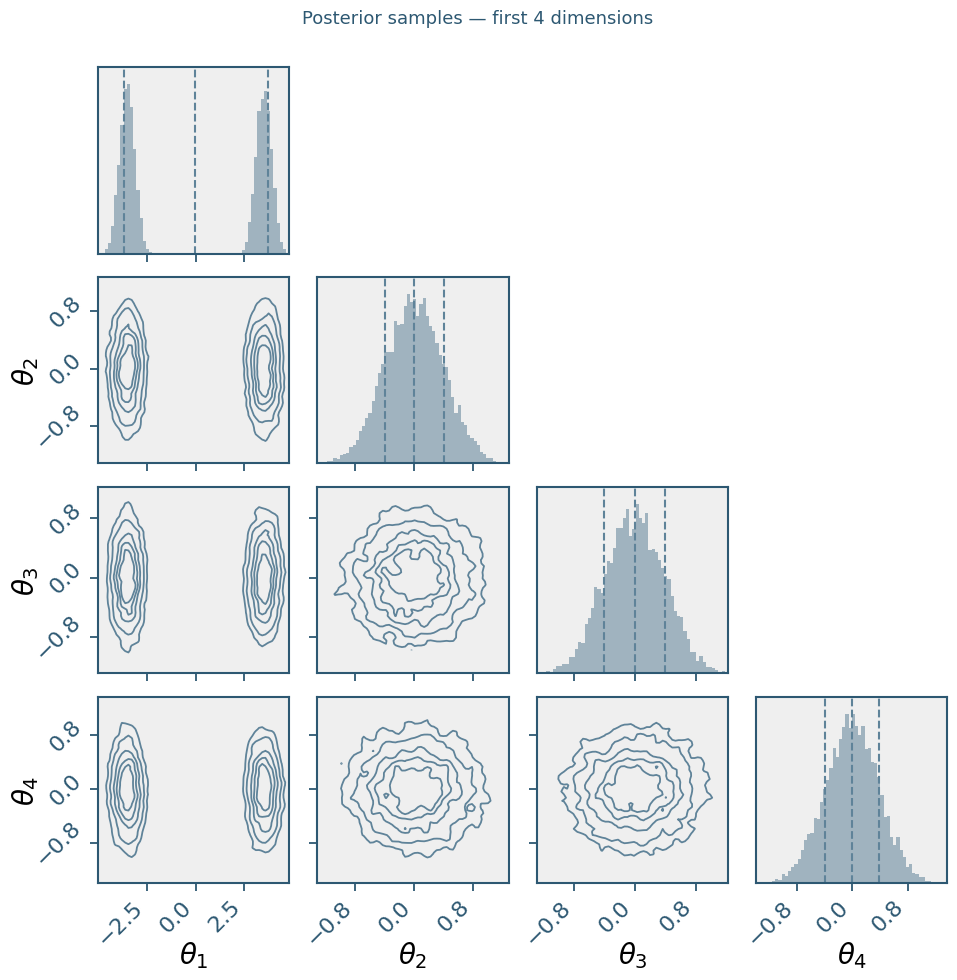

Shell 1 samples: 4000  |  Shell 2 samples: 4000


In [13]:
%matplotlib inline

def styled_corner(samples, labels=(r"$x_1$", r"$x_2$")):
    import numpy as np
    import matplotlib.pyplot as plt
    import corner

    color = "#5f8399"
    facecolor = "#efefef"
    edgecolor = "#2d5872"

    fig = corner.corner(
        samples,
        labels=list(labels),
        bins=60,
        color=color,
        quantiles=[0.16, 0.50, 0.84],
        show_titles=False,
        smooth=1.0,
        smooth1d=None,
        plot_datapoints=False,
        plot_density=False,
        fill_contours=False,
        no_fill_contours=True,
        levels=[0.30, 0.50, 0.68, 0.86, 0.95],
        hist_kwargs={
            "density": True,
            "histtype": "stepfilled",
            "alpha": 0.55,
            "linewidth": 1.5,
        },
        contour_kwargs={"linewidths": 1.3},
        label_kwargs={"fontsize": 20},
        max_n_ticks=4,
    )

    ndim = samples.shape[1]
    axes = np.array(fig.axes).reshape((ndim, ndim))

    for i in range(ndim):
        for j in range(ndim):
            ax = axes[i, j]
            ax.set_facecolor(facecolor)

            for spine in ax.spines.values():
                spine.set_color(edgecolor)
                spine.set_linewidth(1.5)

            ax.tick_params(axis="both", colors=edgecolor, width=1.3, length=6, labelsize=16)

    for ax in axes[-1, :]:
        for label in ax.get_xticklabels():
            label.set_rotation(45)
            label.set_ha("right")

    for ax in axes[:, 0]:
        for label in ax.get_yticklabels():
            label.set_rotation(45)
            label.set_va("center")

    return fig

n_plot_dims = 4
plot_labels = [rf'$\theta_{{{i+1}}}$' for i in range(n_plot_dims)]

fig = styled_corner(post_smp[:, :n_plot_dims], labels=plot_labels)
fig.suptitle('Posterior samples — first 4 dimensions', y=1.01, fontsize=13, color="#2d5872")
plt.tight_layout()
plt.show()

mask_shell1 = post_smp[:, 0] < 0
mask_shell2 = ~mask_shell1
print(f'Shell 1 samples: {mask_shell1.sum()}  |  Shell 2 samples: {mask_shell2.sum()}')


## 10. Estimate ln(Z) with MorphZ

In [14]:
results = evidence(
    post_samples=post_smp,
    log_posterior_values=lp,
    log_posterior_function=lp_fn,
    n_resamples=4000,
    thin=1,
    morph_type='2_group',
    kde_bw='silverman',
    output_path='numpyro_gaussian_shell',
    n_estimations=1,
    verbose=False,
    plot=False,
    show_progress=True,
    overwrite_path=True,
)

results = np.asarray(results)
lnz_est = results[:, 0]
lnz_err = results[:, 1]

true_lnZ = {10: -14.59, 30: -60.13}[ndim]

print(f'MorphZ mean ln(Z): {lnz_est.mean():.4f} ± {lnz_err.mean():.4f}')
print(f'True   ln(Z) D={ndim}: {true_lnZ}')
print(f'Residual: {lnz_est.mean() - true_lnZ:+.4f}')

MI pairs:   0%|          | 0/435 [00:00<?, ?it/s]

Evaluating proposal samples:   0%|          | 0/4000 [00:00<?, ?it/s]

MorphZ mean ln(Z): -60.1273 ± 0.0215
True   ln(Z) D=30: -60.13
Residual: +0.0027


## 11. Summary

The key steps for using NumPyro + MorphZ on a **multimodal** problem are:

| Step | What to do |
|------|------------|
| Model | Use `numpyro.factor` to inject a custom log-likelihood |
| Sampling | Run multiple chains initialised near each mode |
| Combine | Concatenate chains into a single `(n_draws, ndim)` array |
| Check | Corner plot to confirm both modes are present in the samples |
| Log-posterior | Wrap `log_density` so `lp_fn(sample_vec)` returns a scalar |
| Evidence | Pass `post_smp`, `lp`, and `lp_fn` to `morphZ.evidence()` |

> **Note:** For problems where you cannot initialise chains near every mode (unknown number of modes, high-dimensional, etc.), consider using a nested sampler (e.g., dynesty) or parallel tempering to generate the posterior samples instead of NUTS.